# ***Employee Attrition Prediction using HR Analytics***

## **Name – Nilesh Sonawane (IT)**

## Project Title:     Employee Attrition Prediction using HR Analytics

This project aims to predict employee attrition using machine learning techniques based on employee demographic, job-related, and performance data. The project follows a complete machine learning pipeline including data loading, exploratory data analysis (EDA), data preprocessing, feature encoding, model training, and model evaluation. The objective is to identify employees who are likely to leave the organization and help HR departments make data-driven decisions for employee retention.

Pandas is used for data loading, cleaning, and manipulation.

NumPy is used for numerical computations and array operations.

Matplotlib is used to create charts and graphical visualizations.

Seaborn is used for advanced statistical data visualization and analysis.

train_test_split: Used to divide the dataset into training and testing sets for model evaluation.

Logistic Regression: Used to build a classification model for predicting employee attrition (Yes/No).

Decision Tree Classifier: Used to create a tree-based predictive model for employee attrition analysis.

Gaussian Naive Bayes: Used to build a probabilistic classification model based on Bayes' theorem.

metrics: Used to evaluate model performance using measures such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

| Library    | Use                                  |
| ---------- | ------------------------------------ |
| pandas     | Data handling / manipulation         |
| numpy      | Numerical operations / math          |
| matplotlib | Basic plotting / graphs              |
| seaborn    | Advanced visualization / stats plots |


*   Load csv(excel) file



In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

#**EDA Opreations(Exploratory Data Analysis)**

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---> it shows 1st five eow and all columns from dataset

In [ ]:

df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


---> it shows last 5 rows and all columns from dataset

In [ ]:
df.shape

(1470, 35)

--->tells no. of rows & no. of columns

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

---> it is used to display the column names of a DataFrame.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

--->is used to display a summary of the DataFrame.

In [ ]:
cols_to_drop=["YearsInCurrentRole","JobLevel","MaritalStatus","NumCompaniesWorked","StockOptionLevel"]
df = df.drop(cols_to_drop, axis=1, errors='ignore')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,11,3,1,80,8,0,1,6,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,23,4,4,80,10,3,3,10,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,15,3,2,80,7,3,3,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,11,3,3,80,8,3,3,8,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,12,3,4,80,6,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,17,3,3,80,17,3,3,5,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,15,3,1,80,9,5,3,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,20,4,2,80,6,0,3,6,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,14,3,4,80,17,3,2,9,0,8


---->This code removes specific columns from a DataFrame safely, and shows the updated DataFrame.

In [ ]:
rename_cols ={"Age":"Employee_Age", "Education":"Education_level"}

---> change column name

In [ ]:
df=df.rename(columns=rename_cols)
df

,Employee_Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education_level,EducationField,EmployeeCount,EmployeeNumber,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,11,3,1,80,8,0,1,6,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,23,4,4,80,10,3,3,10,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,15,3,2,80,7,3,3,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,11,3,3,80,8,3,3,8,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,12,3,4,80,6,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,17,3,3,80,17,3,3,5,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,15,3,1,80,9,5,3,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,20,4,2,80,6,0,3,6,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,14,3,4,80,17,3,2,9,0,8


In [ ]:
df.count()

,0
Employee_Age,1470
Attrition,1470
BusinessTravel,1470
DailyRate,1470
Department,1470
DistanceFromHome,1470
Education_level,1470
EducationField,1470
EmployeeCount,1470
EmployeeNumber,1470


---> shows how many non-missing values each column has in the DataFrame.

In [ ]:
df=df.drop_duplicates()
df.head()

,Employee_Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education_level,EducationField,EmployeeCount,EmployeeNumber,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,11,3,1,80,8,0,1,6,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,23,4,4,80,10,3,3,10,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,15,3,2,80,7,3,3,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,11,3,3,80,8,3,3,8,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,12,3,4,80,6,3,3,2,2,2


 --->  removes duplicate rows from the DataFrame and shows the first 5 rows to verify the changes.

In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Employee_Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
DistanceFromHome,0.0
Education_level,0.0
EducationField,0.0
EmployeeCount,0.0
EmployeeNumber,0.0


---> This line calculates the percentage of missing values in each column of the DataFrame.

#**Outlier Detection and Treatment**

**Why Outliers?**

---> Outliers are unusual values that can mislead analysis, so we handle them.



**Use of Outliers:**

---> Outliers help us identify unusual behavior, errors, or important patterns in data and improve model accuracy.

**Outlier Detection**

## --->Select Numerical Columns





In [ ]:
num_cols = [
    'Employee_Age', 'DailyRate', 'DistanceFromHome',
    'Education_level', 'EnvironmentSatisfaction',
    'HourlyRate', 'JobInvolvement', 'JobSatisfaction',
    'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike',
    'PerformanceRating', 'RelationshipSatisfaction',
    'StandardHours', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

df_num = df[num_cols]


It only creates a new DataFrame (df_num) that contains selected numerical columns.

##-->Boxplot – Outlier Detection

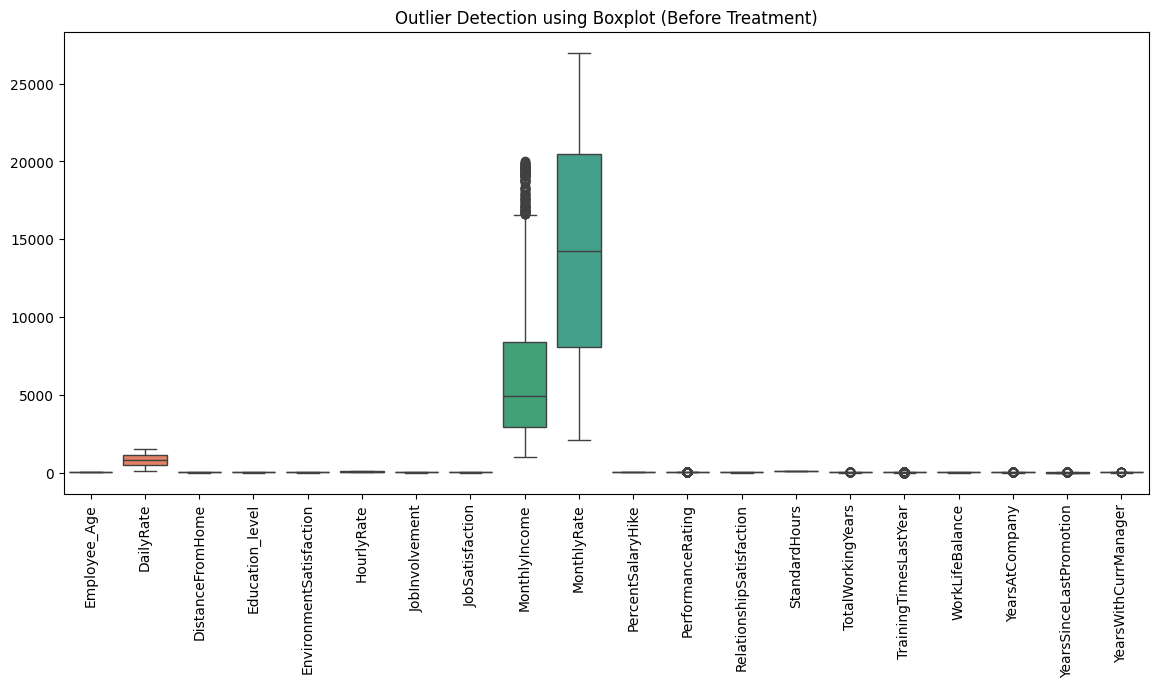

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_num)
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplot (Before Treatment)")
plt.show()


It helps to visually detect outliers in numerical columns so we know which values might distort analysis or affect model accuracy.




##-->IQR Method – Outlier Detection

In [ ]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_num < (Q1 - 1.5 * IQR)) |
            (df_num > (Q3 + 1.5 * IQR)))

print("Outliers count per column:")
print(outliers.sum())


Outliers count per column:
Employee_Age                  0
DailyRate                     0
DistanceFromHome              0
Education_level               0
EnvironmentSatisfaction       0
HourlyRate                    0
JobInvolvement                0
JobSatisfaction               0
MonthlyIncome               114
MonthlyRate                   0
PercentSalaryHike             0
PerformanceRating           226
RelationshipSatisfaction      0
StandardHours                 0
TotalWorkingYears            63
TrainingTimesLastYear       238
WorkLifeBalance               0
YearsAtCompany              104
YearsSinceLastPromotion     107
YearsWithCurrManager         14
dtype: int64


To find and count extreme values (outliers) in each column before cleaning the data.

##--->Outlier Treatment –

In [ ]:
for col in num_cols:
    lower_limit = Q1[col] - 1.5 * IQR[col]
    upper_limit = Q3[col] + 1.5 * IQR[col]

    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])


To treat outliers by capping extreme values instead of removing data

##Boxplot – After Outlier Treatment-

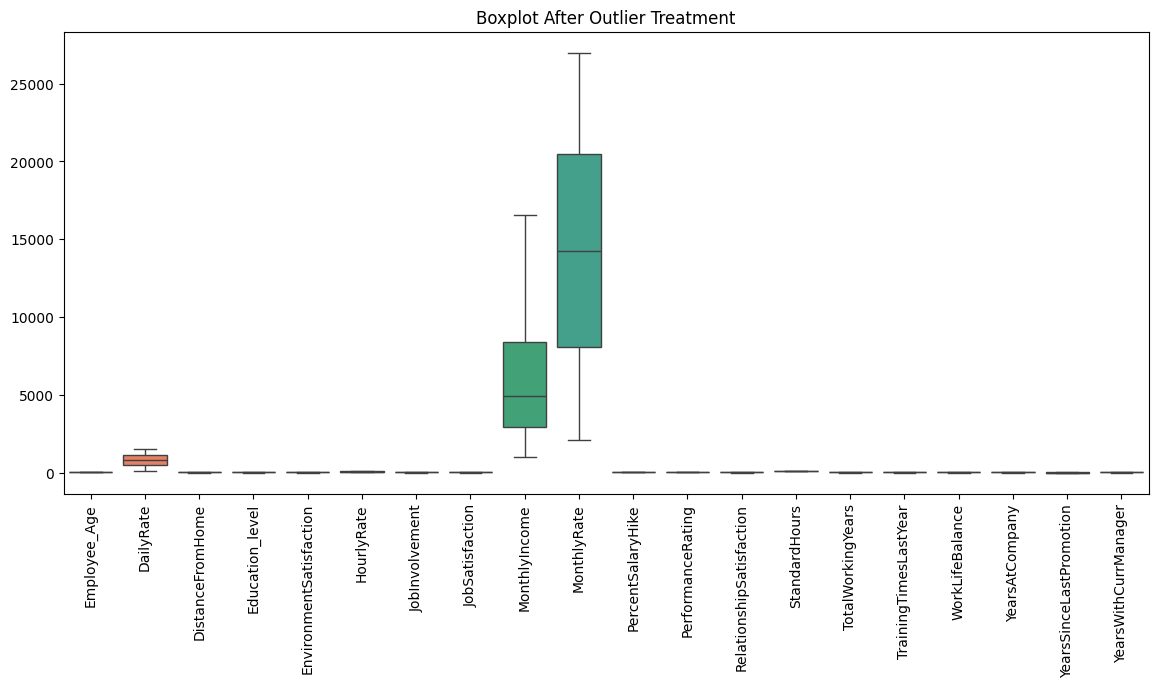

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Treatment")
plt.show()


confirm that outliers are reduced or handled after treatment.

#**DATA CLEANING – COMPLETE OPERATIONS**

###Check Dataset Shape (Before Cleaning)

In [ ]:
print("Shape before cleaning:", df.shape)


Shape before cleaning: (1470, 30)


original size of the dataset before cleaning operations.

###Remove Duplicate Records

In [ ]:
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (1470, 30)


To remove repeated data and ensure clean and accurate analysis.

###Check Columns with Constant Values

In [ ]:
df.nunique()


,0
Employee_Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education_level,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


Shows how many unique values are present in each column.

###Drop Unnecessary / Constant Columns

In [ ]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours']

df.drop(columns=drop_cols, inplace=True)
print("Columns after dropping unnecessary columns:")
print(df.columns)


Columns after dropping unnecessary columns:
Index(['Employee_Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education_level', 'EducationField',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


 reduce noise and keep only useful features for analysis and modeling.

###Check Data Types

In [ ]:
print(df.dtypes)


Employee_Age                float64
Attrition                    object
BusinessTravel               object
DailyRate                   float64
Department                   object
DistanceFromHome            float64
Education_level             float64
EducationField               object
EmployeeNumber                int64
EnvironmentSatisfaction     float64
Gender                       object
HourlyRate                  float64
JobInvolvement              float64
JobRole                      object
JobSatisfaction             float64
MonthlyIncome               float64
MonthlyRate                 float64
OverTime                     object
PercentSalaryHike           float64
PerformanceRating           float64
RelationshipSatisfaction    float64
TotalWorkingYears           float64
TrainingTimesLastYear       float64
WorkLifeBalance             float64
YearsAtCompany              float64
YearsSinceLastPromotion     float64
YearsWithCurrManager        float64
dtype: object


 understand column types before encoding and modeling

###Convert Target Variable (Attrition) into Numeric

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


Converts the Attrition column from Yes/No to 1/0

###Final Dataset Overview

In [ ]:
print("Final shape after data cleaning:", df.shape)
df.head()


Final shape after data cleaning: (1470, 27)


,Employee_Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education_level,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,1,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1,2.0,...,Yes,11.0,3.0,1.0,8.0,0.5,1.0,6.0,0.0,5.0
1,49.0,0,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,2,3.0,...,No,23.0,3.0,4.0,10.0,3.0,3.0,10.0,1.0,7.0
2,37.0,1,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,4,4.0,...,Yes,15.0,3.0,2.0,7.0,3.0,3.0,0.0,0.0,0.0
3,33.0,0,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,5,4.0,...,Yes,11.0,3.0,3.0,8.0,3.0,3.0,8.0,3.0,0.0
4,27.0,0,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,7,1.0,...,No,12.0,3.0,4.0,6.0,3.0,3.0,2.0,2.0,2.0


#**DATA Visualization**

--->*Import Libraries*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


#Attrition Distribution (Target Variable)

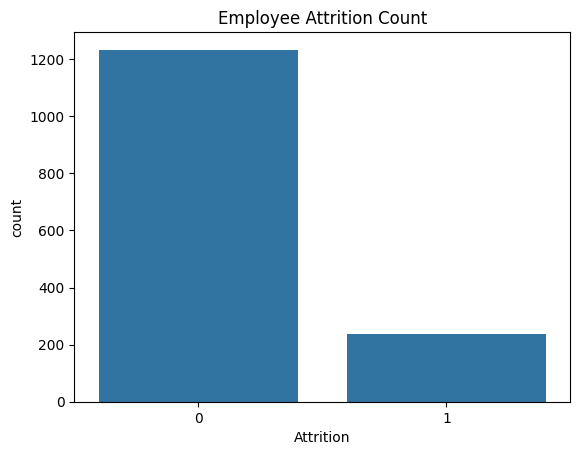

In [ ]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()


#

Shows how many employees left vs stayed

#Age vs Attrition (Boxplot)

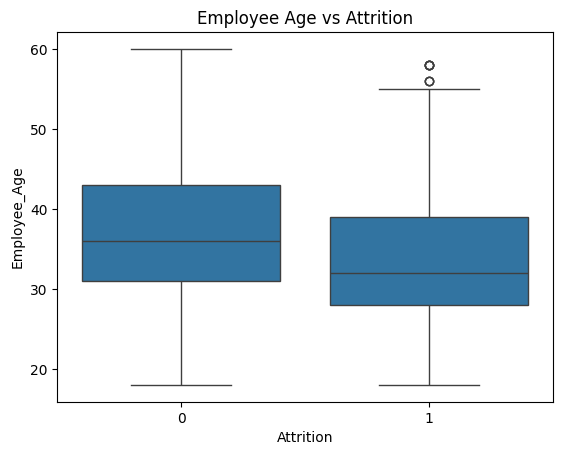

In [ ]:
sns.boxplot(x='Attrition', y='Employee_Age', data=df)
plt.title("Employee Age vs Attrition")
plt.show()


Check if Employee age affects attrition

#Monthly Income Distribution (Histogram)

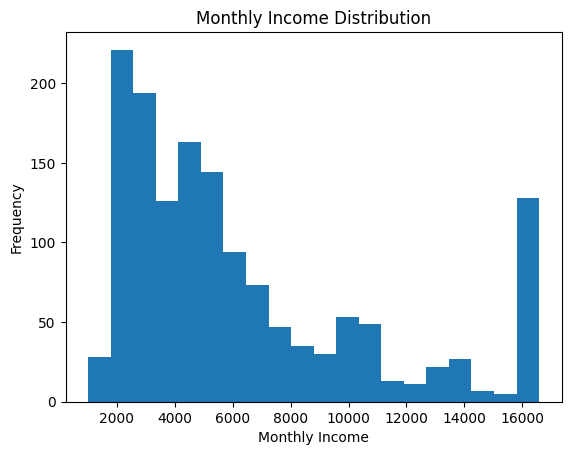

In [ ]:
plt.hist(df['MonthlyIncome'], bins=20)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()


Understand salary distribution

#Attrition vs Monthly Income (Boxplot)

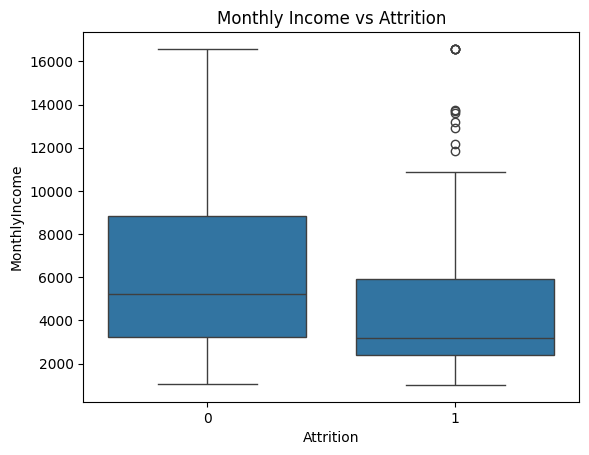

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()


it shows Income impact on attrition

#Job Satisfaction vs Attrition (Bar Plot)

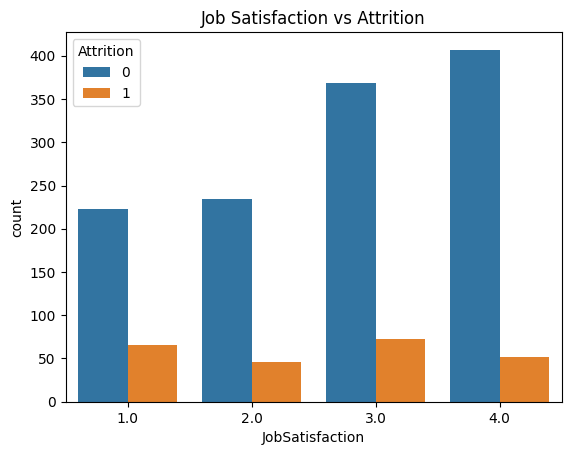

In [ ]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()


Relationship between satisfaction and attrition

#**Feature Encoding & Scaling**

#Separate Features and Target( OneHotEncoder)

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']


This code splits the data into **inputs (`X`)** and **output (`y`)**.


#Identify Categorical and Numerical Columns

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'OverTime'],
      dtype='object')
Numerical Columns: Index(['Employee_Age', 'DailyRate', 'DistanceFromHome', 'Education_level',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


This code lists which columns in X are categorical (text) and which are numerical (numbers).

#Import Required Classes

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


#Create Preprocessing Object (Encoding + Scaling)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)


This code **prepares numeric and categorical data for ML**.


#Apply Encoding & Scaling

In [ ]:
X_processed = preprocessor.fit_transform(X)


This code **transforms `X` into a processed form ready for ML**.


#**ML Models Implemented**

#**---> Import Required Libraries (scikit-learn)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


Define Features (X) and Target (y)

In [ ]:

y = df['Attrition']

X = df.drop('Attrition', axis=1)


This code **sets `y` as the target and `X` as the input features**.


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


This code **splits the data into training (80%) and testing (20%) sets**, keeping the target proportion the same in both.


#**---> Logistic Regression**

Train the Model

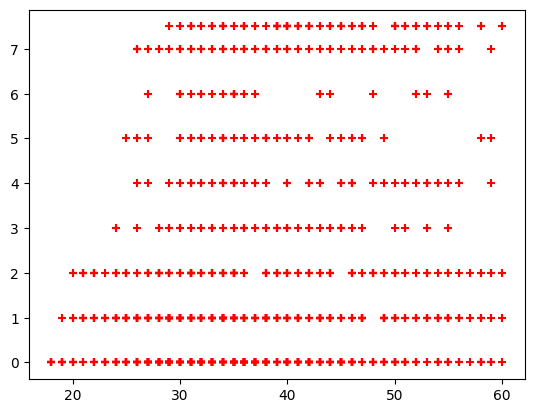

In [ ]:
plt.scatter(df.Employee_Age, df.YearsSinceLastPromotion, marker='+', color='red')

This code **plots age vs years since last promotion**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['Employee_Age']],
                                                    df.Attrition, train_size=0.8)

This code **splits `Employee_Age` and `Attrition` into 80% training and 20% testing sets**.



In [ ]:
X_test

,Employee_Age
1307,28.0
1425,33.0
1385,34.0
884,40.0
939,32.0
...,...
664,36.0
104,37.0
1148,39.0
43,27.0


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

This code **creates a Logistic Regression model** for training.


In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
X_test

,Employee_Age
1307,28.0
1425,33.0
1385,34.0
884,40.0
939,32.0
...,...
664,36.0
104,37.0
1148,39.0
43,27.0


In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
model.predict_proba(X_test)

array([[0.78852696, 0.21147304],
       [0.82777274, 0.17222726],
       [0.83489091, 0.16510909],
       [0.87273054, 0.12726946],
       [0.82041369, 0.17958631],
       [0.79686913, 0.20313087],
       [0.771099  , 0.228901  ],
       [0.88358871, 0.11641129],
       [0.94734829, 0.05265171],
       [0.82041369, 0.17958631],
       [0.88358871, 0.11641129],
       [0.90290662, 0.09709338],
       [0.87273054, 0.12726946],
       [0.87273054, 0.12726946],
       [0.80496361, 0.19503639],
       [0.93624827, 0.06375173],
       [0.93624827, 0.06375173],
       [0.83489091, 0.16510909],
       [0.87273054, 0.12726946],
       [0.88871015, 0.11128985],
       [0.74311349, 0.25688651],
       [0.78852696, 0.21147304],
       [0.80496361, 0.19503639],
       [0.84841669, 0.15158331],
       [0.83489091, 0.16510909],
       [0.81281131, 0.18718869],
       [0.84841669, 0.15158331],
       [0.79686913, 0.20313087],
       [0.89836377, 0.10163623],
       [0.80496361, 0.19503639],
       [0.

This code **calculates the predicted probabilities for each class on the test data**.


In [ ]:
model.score(X_test, y_predicted)

1.0

This code **calculates the accuracy of the model by comparing predictions (`y_predicted`) with the true test labels**.


In [ ]:
from sklearn.metrics import accuracy_score

Y_predicted = model.predict(X_test)
accuracy = accuracy_score(y_test, y_predicted)
print("Accuracy : ", accuracy)

Accuracy :  0.8163265306122449


This code predicts the target for test data and prints the model’s accuracy.

In [ ]:
y_predicted


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

model.coef_indicates value of m in y=m*x+b equation

In [ ]:
model.coef_

array([[-0.05077094]])

model.intercept_ indicates value of b in y= m*x + b equation

In [ ]:
model.intercept_

array([0.10551718])

Lets defined sigmoide function now and do math with hand

In [ ]:
import math
def sigmoid(X):
  return 1 / (1 + math.exp(-X))

In [ ]:
def prediction_function(age):
  z = 0.042 * age - 1.53 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
  y = sigmoid(z)
  return y

This code **predicts attrition probability from age**.


In [ ]:
Employee_Age = 49
prediction_function(Employee_Age)

0.6290165230447227

0.485 is less than 0.5 which means person with 35 age will not buy insurance

#**----> Decission Tree classifier**



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']


This code **splits the data into inputs (`X`) and target (`y`)**.


In [ ]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

This code **splits the preprocessed data into training (80%) and testing (20%) sets**.


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)


This code **creates a Decision Tree model with a maximum depth of 5 using the Gini criterion**.


In [ ]:
dt_model.fit(X_train_dt, y_train_dt)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test_dt)


In [ ]:
accuracy_score(y_test, y_pred)


0.7619047619047619

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


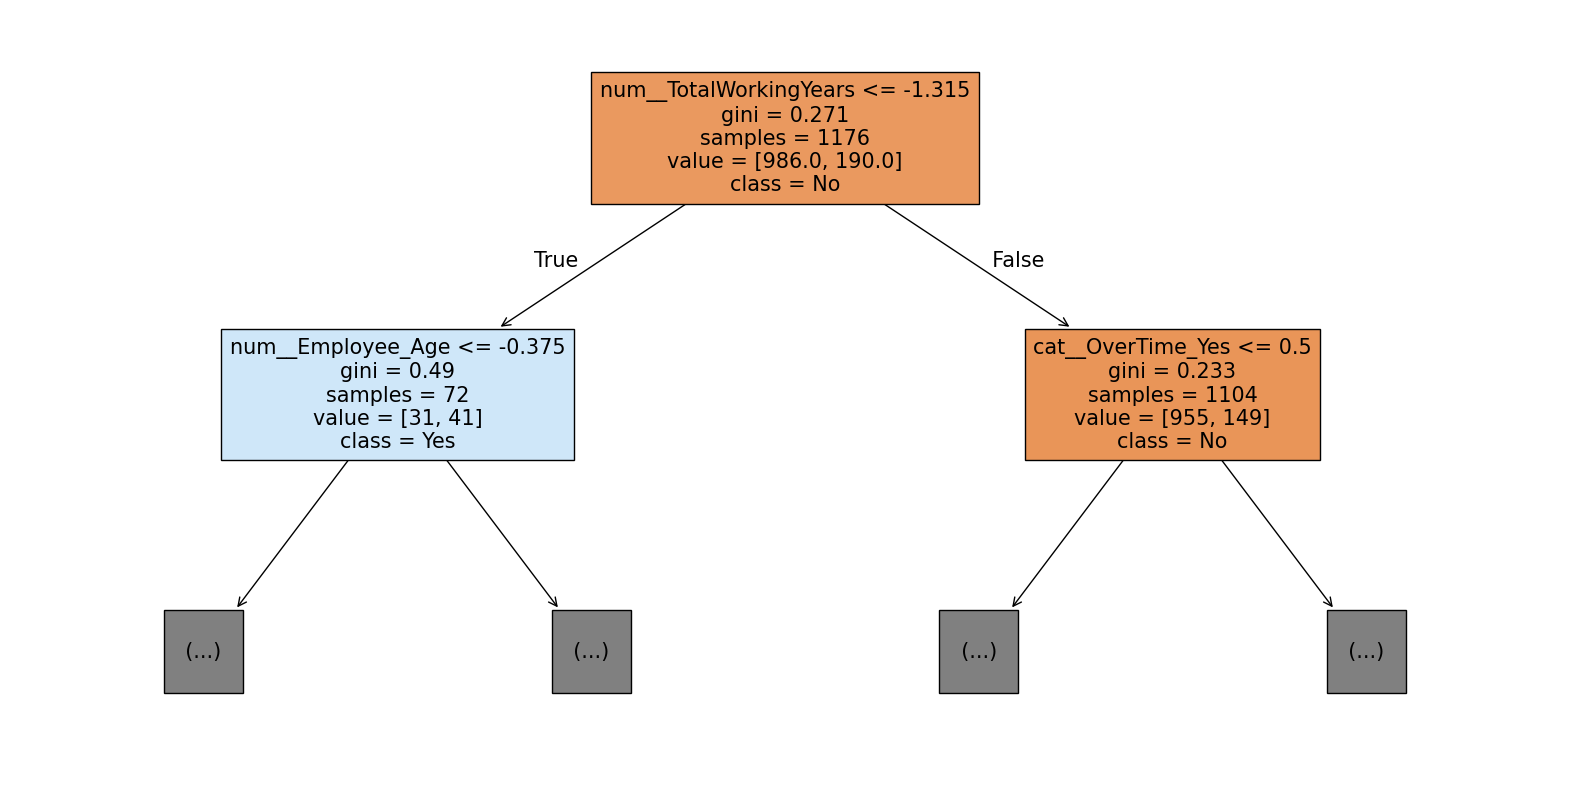

In [ ]:
plt.figure(figsize=(20,10))
# Get the feature names after preprocessing
processed_feature_names = preprocessor.get_feature_names_out()

plot_tree(
    dt_model,
    feature_names=processed_feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    max_depth=1
)
plt.show()


This code **plots the top level (depth 1) of the decision tree with feature names and class labels**.


#**----> Naive Bayes classifier**

In [ ]:
df.isnull().sum()


,0
Employee_Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education_level,0
EducationField,0
EmployeeNumber,0
EnvironmentSatisfaction,0


In [ ]:
X = X_processed
y = df['Attrition'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X, y, test_size=0.25, random_state=0
)

This code **splits the data into 75% training and 25% testing sets for a Naive Bayes model**.


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_gnb = sc.fit_transform(X_train_gnb)
X_test_gnb = sc.transform(X_test_gnb)

code **scales the features so they have mean 0 and standard deviation 1** for the Naive Bayes model.


In [ ]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train_gnb, y_train_gnb)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test_gnb)

#**Model Evalution**

#Confusion Matrix Heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_gnb, y_pred)

array([[199, 111],
       [ 19,  39]])

In [ ]:
cm = confusion_matrix(y_test_gnb, y_pred)

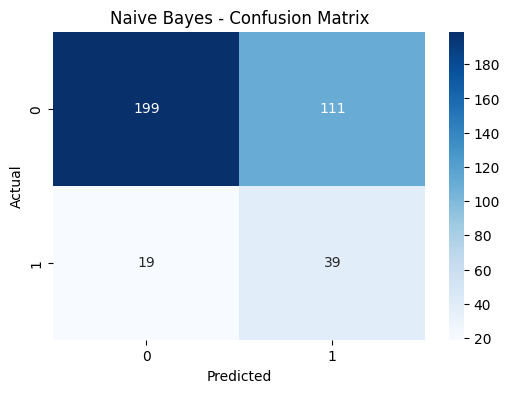

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

This code **plots a heatmap of the confusion matrix to show how well the Naive Bayes model predicted each class**.


#ROC curve

In [ ]:
from sklearn.metrics import roc_curve, auc
y_prob = classifier.predict_proba(X_test_gnb)[:, 1]

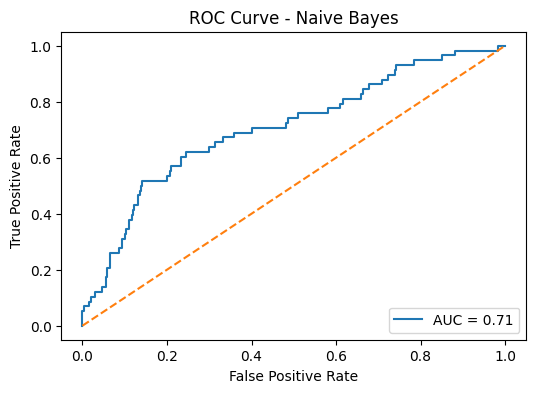

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_gnb, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc='lower right')
plt.show()

This code **plots the ROC curve and shows the AUC to evaluate the Naive Bayes model’s performance**.


#**Conclusion**

In this project, employee attrition data was analyzed and preprocessed to build effective machine learning models.
Different algorithms were implemented and evaluated, and Logistic Regression performed well for predicting employee attrition.
The results help in identifying key factors influencing employee turnover and can support better decision-making in organizations.